100%|██████████| 170M/170M [01:04<00:00, 2.63MB/s]


Starting training...
Epoch 1, Loss: 1.4709
Epoch 2, Loss: 1.1236
Epoch 3, Loss: 0.9792
Epoch 4, Loss: 0.8723
Epoch 5, Loss: 0.7923
Epoch 6, Loss: 0.7243
Epoch 7, Loss: 0.6673
Epoch 8, Loss: 0.6121
Epoch 9, Loss: 0.5575
Epoch 10, Loss: 0.5141
Training complete.
Accuracy on test data: 69.54%


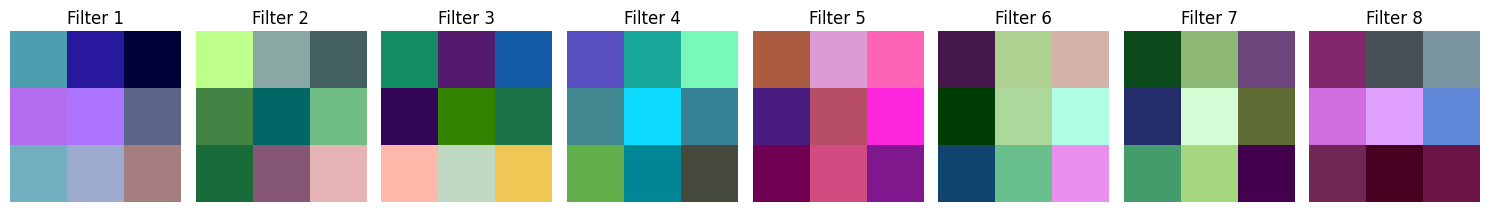

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision
import matplotlib.pyplot as plt

# Step 1: Load and Normalize CIFAR-10 Dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True,
transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True,
transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

classes = trainset.classes

# Step 2: Define CNN Architecture
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)   # Output: 16x32x32
        self.pool = nn.MaxPool2d(2, 2)                # Output: 16x16x16
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)  # Output: 32x16x16 -> 32x8x8 after pooling
        self.fc1 = nn.Linear(32 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(-1, 32 * 8 * 8)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Step 3: Train the CNN
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN().to(device)

lossfn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Starting training...")
for epoch in range(10):
    running_loss = 0.0
    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = lossfn(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {running_loss / len(trainloader):.4f}")
print("Training complete.")

# Step 4: Evaluate Model Performance
correct, total = 0, 0
with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Accuracy on test data: {100 * correct / total:.2f}%")

# Step 5: Visualize Learned Filters
def visualize_filters(layer, n_filters=8):
    filters = layer.weight.data.clone().cpu()
    fig, axs = plt.subplots(1, n_filters, figsize=(15, 4))
    for i in range(n_filters):
        f = filters[i]
        f = (f - f.min()) / (f.max() - f.min())  # Normalize for display
        # Filters for Conv2d are usually (out_channels, in_channels, height, width)
        # For display, we might want to take one of the in_channels (e.g., the first one)
        # and display it as grayscale, or average across in_channels if it's 3D.
        # Assuming it's a 3-channel input for the first layer, take the first channel if it's not a single channel filter.
        if f.dim() == 4 and f.shape[1] > 1: # If it's a color filter, take the first input channel for display
            f = f[0]
        elif f.dim() == 4: # Grayscale filter for multiple input channels
            f = f.mean(dim=1) # Average across input channels if it's still 4D

        # Handle case where filter might be 2D after previous operations (e.g., f.shape is (h,w) )
        if f.dim() == 3: # If it's (C, H, W), permute to (H, W, C) for imshow
            f = f.permute(1, 2, 0)
        elif f.dim() == 2: # If it's (H, W), no permute needed
            pass
        else:
            # If it's 1D or something unexpected, try to convert to 2D for imshow
            f = f.squeeze() # Remove singleton dimensions
            if f.dim() > 2:
                 f = f[0] # Take first 'slice' if it's still 3D or more
            if f.dim() == 1: # If still 1D, reshape to a square if possible
                side = int(f.shape[0]**0.5)
                if side * side == f.shape[0]:
                    f = f.reshape(side, side)
                else:
                    print(f"Warning: Filter {i+1} has unexpected shape {filters[i].shape}. Cannot visualize effectively.")
                    continue

        axs[i].imshow(f.cpu().numpy(), cmap='gray' if f.dim() == 2 else None)
        axs[i].axis('off')
        axs[i].set_title(f'Filter {i+1}')
    plt.tight_layout()
    plt.show()

visualize_filters(model.conv1)